# Phan doan khoi u nao BraTS 2023

Notebook huan luyen va danh gia **3D U-Net / Swin UNETR** bang PyTorch + MONAI.

Pipeline nay dung NIfTI 3D da dong dang cua BraTS, luu cache NPZ kem affine/spacing,
chon checkpoint bang full validation va bao cao ket qua cuoi tren held-out test set.

> Research use only. Ket qua khong thay the danh gia cua bac si chan doan hinh anh.

## 1. Cài đặt các thư viện phụ thuộc

In [ ]:
# Install into the active notebook kernel. Version ranges avoid unreviewed major upgrades.
%pip install -q "monai>=1.3,<2.0" "nibabel>=5.2,<6" "fpdf2>=2.7,<3" \
  "matplotlib>=3.7,<4" "tqdm>=4.66,<5" "scikit-learn>=1.3,<2" "scipy>=1.11,<2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 337.0/337.0 kB 33.9 MB/s eta 0:00:00


In [ ]:
import inspect
import os
import random
import shutil
import time
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union
from zipfile import BadZipFile

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import torch
from scipy.ndimage import binary_erosion, distance_transform_edt
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
from tqdm.notebook import tqdm

import monai.transforms as mt
from monai.data import DataLoader as MonaiDataLoader
from monai.inferers import sliding_window_inference
from monai.losses import DiceCELoss
from monai.networks.nets import SwinUNETR, UNet
from monai.utils import set_determinism

## 2. Mount Google Drive và Thiết lập Thiết bị

In [ ]:
# Mount Google Drive only when running in Colab. Check MyDrive, not the mount directory alone.
IN_COLAB = False
try:
    from google.colab import drive

    IN_COLAB = True
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive", force_remount=False)
    if not Path("/content/drive/MyDrive").exists():
        raise RuntimeError("Google Drive mount failed: /content/drive/MyDrive is unavailable")
    print("Google Drive is ready")
except ImportError:
    print("Running outside Google Colab")

Mounted at /content/drive
Google Drive is ready


In [ ]:
# Reproducibility across Python, NumPy, PyTorch, MONAI transforms and DataLoader workers.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
set_determinism(seed=SEED)
torch.backends.cudnn.benchmark = False # tắt chế độ benchmark (chế độ này chọn thuật toán tối ưu nhưng có thể không tái lập).
torch.backends.cudnn.deterministic = True # buộc các phép toán dùng thuật toán deterministic (kết quả giống nhau mỗi lần chạy).

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {props.total_memory / (1024 ** 3):.2f} GB")

Device: cuda
GPU: Tesla T4
VRAM: 14.56 GB


In [ ]:
# Paths
raw_dir = Path("/content/drive/MyDrive/BraTS2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData")
npz_dir = Path("/content/drive/MyDrive/BraTS2023/processed_npz")

data_root = raw_dir if raw_dir.exists() else None
drive_npz_dir = npz_dir if npz_dir.exists() and len(list(npz_dir.glob("*.npz"))) > 0 else None
local_npz_dir = Path("/content/processed_npz") if IN_COLAB else npz_dir

checkpoints_dir = Path("/content/drive/MyDrive/BraTS2023/checkpoints") if IN_COLAB else Path("checkpoints")
reports_dir = Path("/content/drive/MyDrive/BraTS2023/reports") if IN_COLAB else Path("reports")
predictions_dir = Path("/content/drive/MyDrive/BraTS2023/predictions") if IN_COLAB else Path("predictions")

# Tạo thư mục nếu chưa có
checkpoints_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)
predictions_dir.mkdir(parents=True, exist_ok=True)

# Data and experiment configuration
PREPROCESS_VERSION = "brats_npz_v3_affine_spacing_strict_labels"
FORCE_REBUILD_CACHE = False
MODALITIES = ("t1n", "t1c", "t2w", "t2f")
LABEL_MAP = {0: 0, 1: 1, 2: 2, 3: 3, 4: 3}
ALLOWED_RAW_LABELS = set(LABEL_MAP)

VAL_SPLIT = 0.15        # Tỉ lệ dữ liệu dành cho validation (15%)
TEST_SPLIT = 0.15       # Tỉ lệ dữ liệu dành cho test (15%)
VAL_SUBSET_SIZE = 20    # Giới hạn số lượng mẫu validation (20 mẫu)
PATCH_SIZE = (96, 96, 96)  # Kích thước patch 3D cắt từ ảnh MRI (96x96x96 voxel)
BATCH_SIZE = 1          # Batch size huấn luyện (1 patch mỗi batch do ảnh 3D rất nặng)
NUM_SAMPLES = 1         # Số lượng mẫu lấy từ mỗi ảnh trong một lần huấn luyện
NUM_WORKERS = 2         # Số worker dùng để load dữ liệu song song
STEPS_PER_EPOCH = 150   # Số bước huấn luyện trong mỗi epoch
MAX_EPOCHS = 30         # Tổng số epoch huấn luyện
FAST_VAL_INTERVAL = 2   # Tần suất chạy validation nhanh (mỗi 2 epoch)
FULL_VAL_INTERVAL = 10  # Tần suất chạy validation đầy đủ (mỗi 10 epoch)
SW_BATCH_SIZE = 1       # Batch size cho sliding window inference
SW_OVERLAP = 0.5        # Mức độ chồng lấn giữa các cửa sổ trong sliding window (50%)
LR = 2e-4               # Learning rate cho optimizer
WEIGHT_DECAY = 1e-4     # Hệ số weight decay (regularization)

# Model selection
MODELS_TO_TRAIN = ["unet3d"] 

print(f"Raw data:       {data_root}")
print(f"Drive NPZ:      {drive_npz_dir}")
print(f"Runtime NPZ:    {local_npz_dir}")

Raw data:       /content/drive/MyDrive/BraTS2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData
Drive NPZ:      /content/drive/MyDrive/BraTS2023/processed_npz
Runtime NPZ:    /content/processed_npz


## 3. Tiền xử lý dữ liệu sang định dạng NPZ

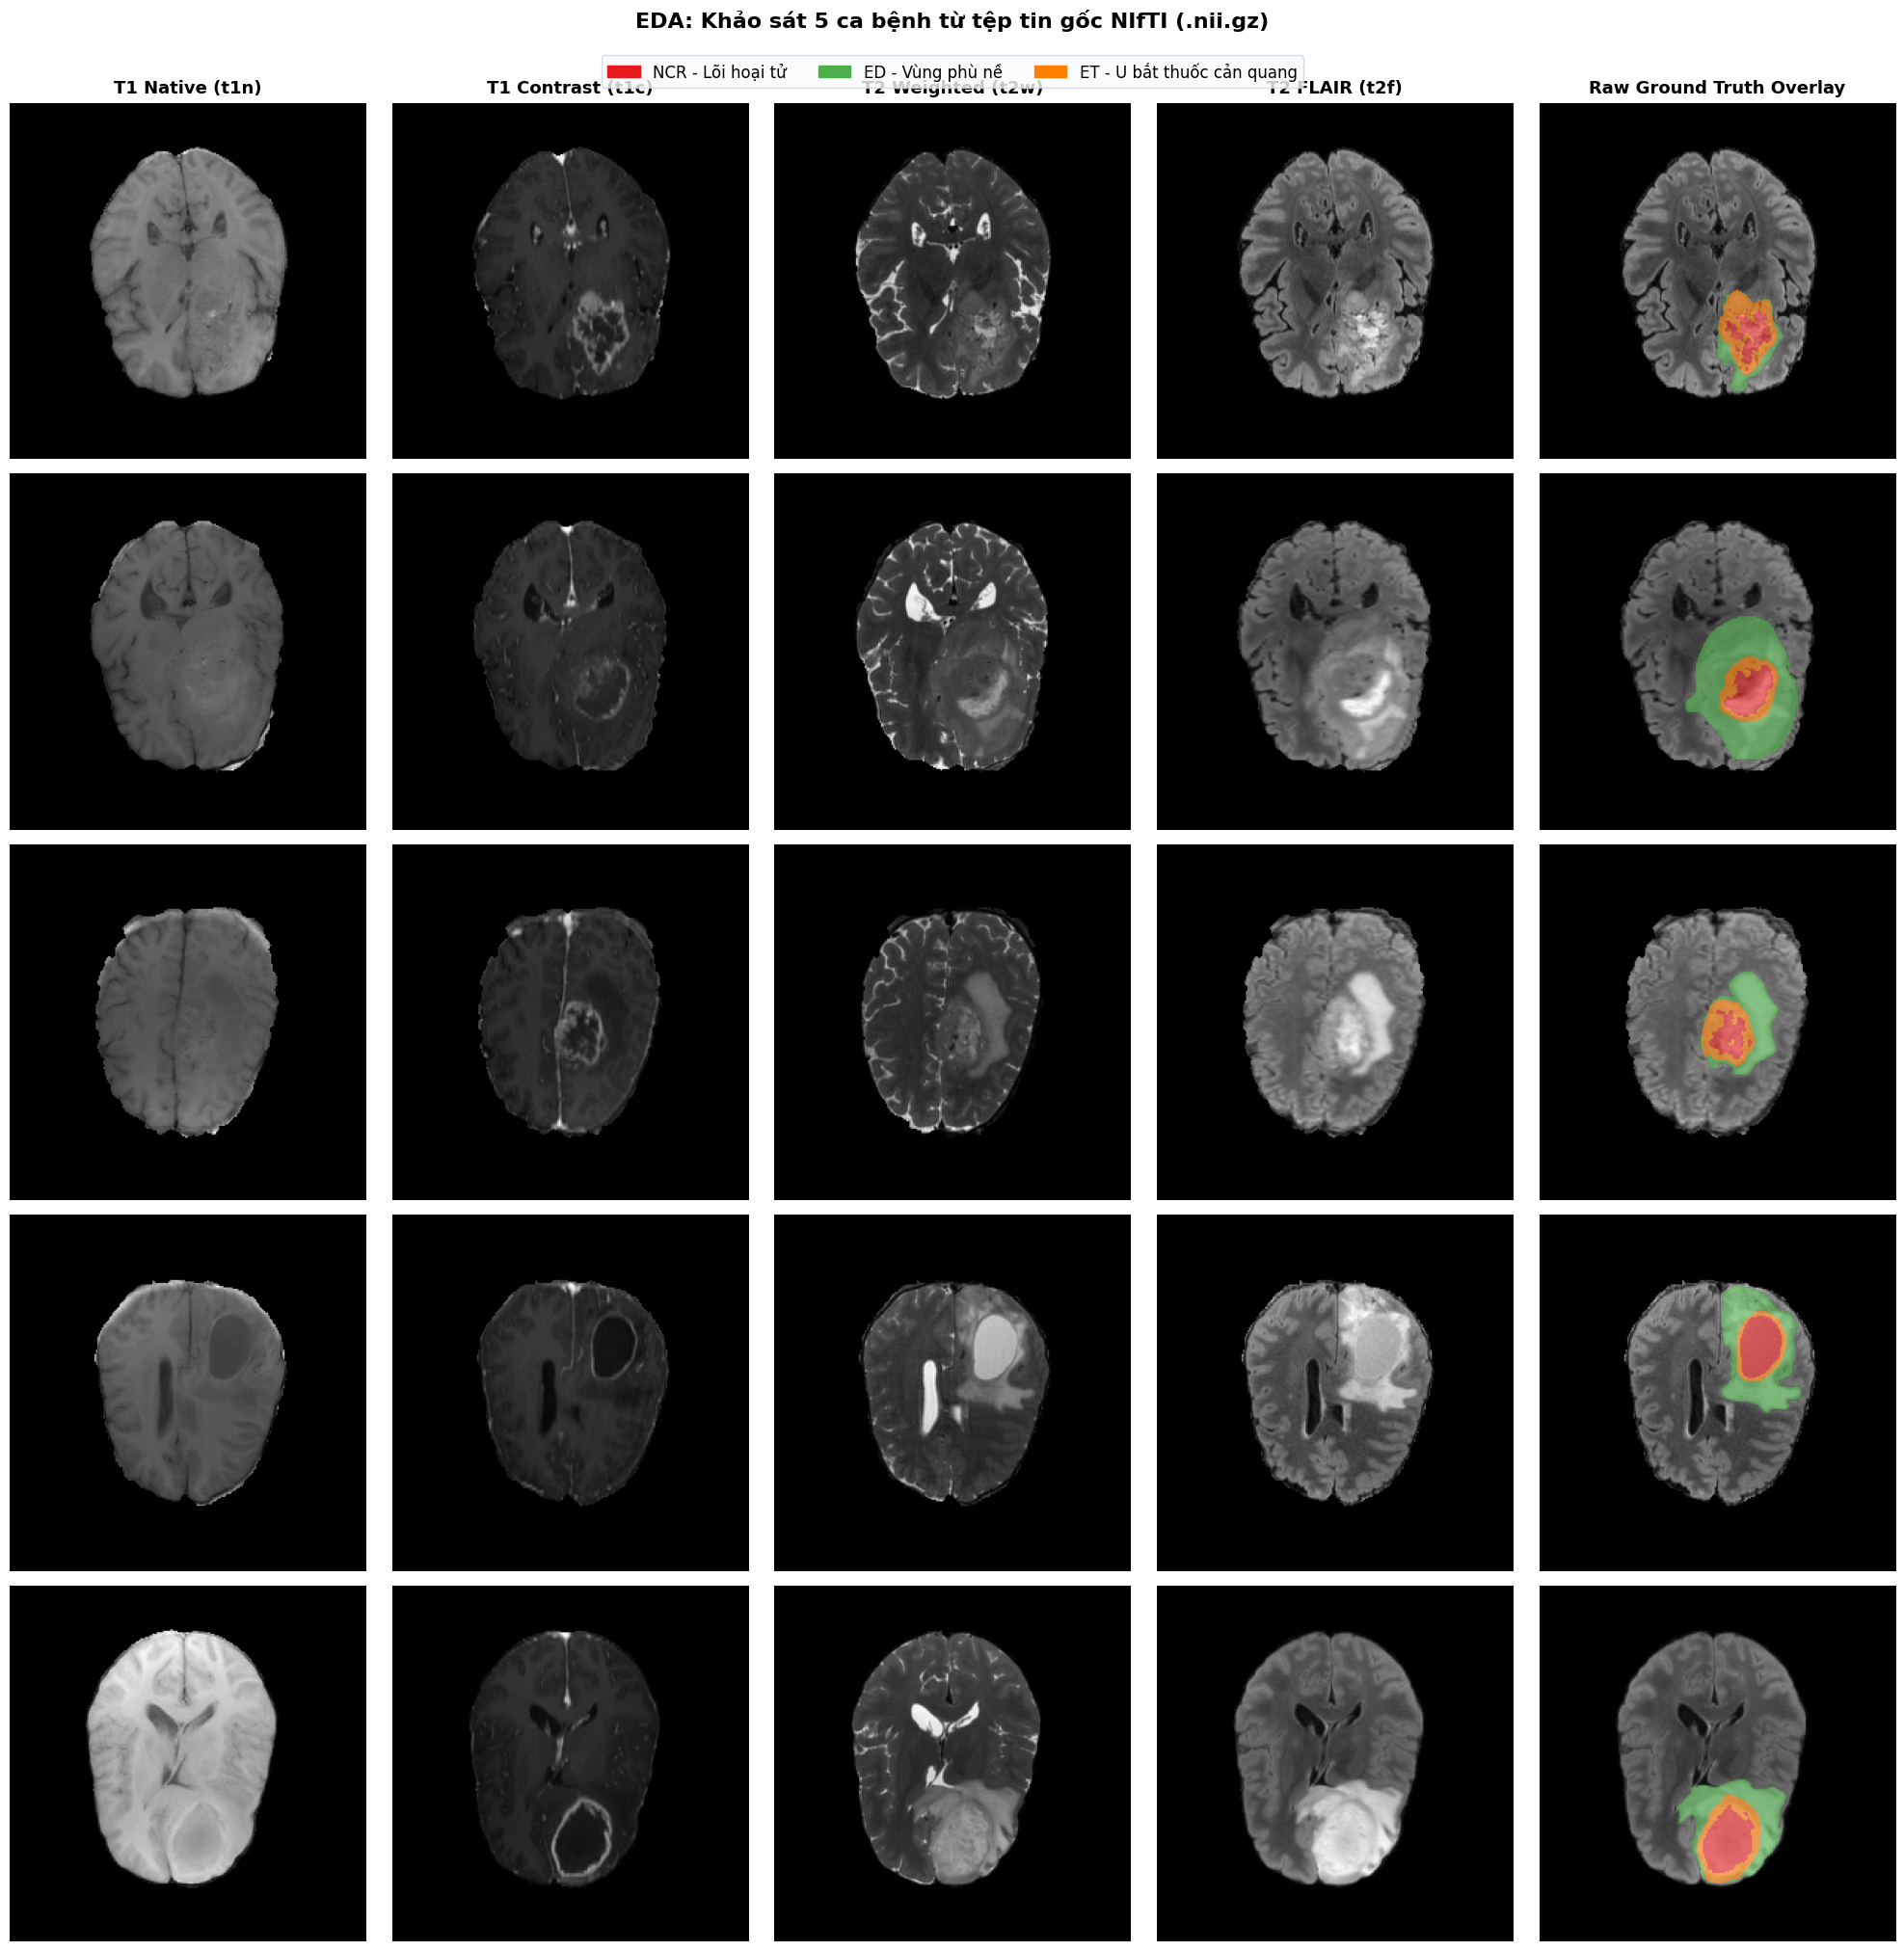

In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

def plot_eda_from_raw_nifti(data_root, num_samples=5):
    """
    Đọc và trực quan hóa 5 ca bệnh mẫu trực tiếp từ các file NIfTI thô (.nii.gz).
    """
    # 1. Lấy danh sách các thư mục ca bệnh raw
    raw_cases = sorted([d.name for d in data_root.iterdir() if d.is_dir() and not d.name.startswith(".")])[:num_samples]
    
    # 2. Bảng màu nhãn u chuẩn (0: Nền trong suốt, 1: Đỏ, 2: Xanh lá, 3: Vàng cam)
    segmentation_cmap = ListedColormap(["none", "#e41a1c", "#4daf4a", "#ff7f00"])
    
    fig, axes = plt.subplots(num_samples, 5, figsize=(20, 4 * num_samples), facecolor="white")
    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    modality_suffixes = ["t1n", "t1c", "t2w", "t2f"]
    modality_names = ["T1 Native (t1n)", "T1 Contrast (t1c)", "T2 Weighted (t2w)", "T2 FLAIR (t2f)"]

    for row_idx, case_id in enumerate(raw_cases):
        case_folder = data_root / case_id
        
        # Đọc file segmentation nhãn u
        seg_path = case_folder / f"{case_id}-seg.nii.gz"
        seg_data = nib.load(seg_path).get_fdata().astype(np.uint8)
        
        # Map nhãn thô BraTS (1, 2, 4 -> 1, 2, 3)
        label_mapped = np.zeros_like(seg_data)
        label_mapped[seg_data == 1] = 1 # NCR
        label_mapped[seg_data == 2] = 2 # ED
        label_mapped[seg_data == 4] = 3 # ET (nhãn 4 trong file gốc map thành 3)
        label_mapped[seg_data == 3] = 3

        # Tìm lát cắt Axial Z có diện tích u lớn nhất
        z_sum = np.sum(label_mapped > 0, axis=(0, 1))
        z_idx = int(np.argmax(z_sum)) if z_sum.max() > 0 else seg_data.shape[2] // 2

        # Đọc và vẽ 4 file chuỗi xung MRI gốc
        flair_slice = None
        for col_idx, mod in enumerate(modality_suffixes):
            nii_path = case_folder / f"{case_id}-{mod}.nii.gz"
            nii_img = nib.load(nii_path).get_fdata()
            slice_data = nii_img[:, :, z_idx]
            
            if mod == "t2f":
                flair_slice = slice_data

            ax = axes[row_idx, col_idx]
            ax.imshow(slice_data.T, cmap="gray", origin="lower")
            if row_idx == 0:
                ax.set_title(modality_names[col_idx], fontsize=13, fontweight="bold", pad=8)
            if col_idx == 0:
                ax.set_ylabel(f"{case_id}\n(Slice Z: {z_idx+1})", fontsize=11, fontweight="bold")
            ax.axis("off")

        # Cột 5: Vẽ ảnh FLAIR đè nhãn Ground Truth Segmentation
        ax_seg = axes[row_idx, 4]
        mask_slice = label_mapped[:, :, z_idx].astype(float)
        mask_slice[mask_slice == 0] = np.nan

        ax_seg.imshow(flair_slice.T, cmap="gray", origin="lower")
        ax_seg.imshow(mask_slice.T, cmap=segmentation_cmap, vmin=0, vmax=3, alpha=0.6, origin="lower")
        if row_idx == 0:
            ax_seg.set_title("Raw Ground Truth Overlay", fontsize=13, fontweight="bold", pad=8)
        ax_seg.axis("off")

    # Legend
    legend_patches = [
        mpatches.Patch(color="#e41a1c", label="NCR - Lõi hoại tử"),
        mpatches.Patch(color="#4daf4a", label="ED - Vùng phù nề"),
        mpatches.Patch(color="#ff7f00", label="ET - U bắt thuốc cản quang"),
    ]
    fig.legend(handles=legend_patches, loc="upper center", bbox_to_anchor=(0.5, 0.99),
               ncol=3, fontsize=12, frameon=True, facecolor="#f8fafc", edgecolor="#cbd5e1")

    plt.suptitle("EDA: Khảo sát 5 ca bệnh từ tệp tin gốc NIfTI (.nii.gz)",
                 fontsize=16, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

# Chạy EDA trực tiếp từ thư mục raw
plot_eda_from_raw_nifti(data_root, num_samples=5)


In [ ]:
CACHE_ERRORS = (OSError, ValueError, TypeError, KeyError, EOFError, BadZipFile)


def load_validated_cache(npz_path: Path) -> Dict[str, np.ndarray]:
    """Load one NPZ cache file flexibly, supporting all preprocessed and custom formats."""
    npz_path = Path(npz_path)
    with np.load(npz_path, allow_pickle=True) as data:
        # 1. Extract Image array
        img_key = next((k for k in ("image", "img", "data", "mri") if k in data), None)
        if img_key is None:
            if len(data.files) > 0:
                img_key = data.files[0]
            else:
                raise ValueError(f"No array found in {npz_path}")
        image = np.asarray(data[img_key])

        # Handle channels-last (H, W, D, 4) -> (4, H, W, D)
        if image.ndim == 4 and image.shape[-1] in (1, 4) and image.shape[0] not in (1, 4):
            image = np.moveaxis(image, -1, 0)
        elif image.ndim == 3:
            image = np.expand_dims(image, axis=0)

        # 2. Extract Label array (support 'label', 'seg', 'mask', 'target')
        lbl_key = next((k for k in ("label", "seg", "mask", "target", "labels") if k in data), None)
        if lbl_key is not None:
            label = np.asarray(data[lbl_key])
            if label.ndim == 4 and label.shape[-1] == 1:
                label = np.squeeze(label, axis=-1)
            if label.ndim == 3:
                label = np.expand_dims(label, axis=0)
            # Remap legacy label 4 -> 3 if present
            if np.any(label == 4):
                label = label.copy()
                label[label == 4] = 3
        else:
            label = np.zeros((1,) + image.shape[1:], dtype=np.uint8)

        # 3. Extract or default Affine
        if "affine" in data and hasattr(data["affine"], "shape") and data["affine"].shape == (4, 4):
            affine = np.asarray(data["affine"], dtype=np.float64)
        else:
            affine = np.eye(4, dtype=np.float64)
        
        # 4. Extract or default Spacing
        if "spacing" in data and hasattr(data["spacing"], "__len__") and len(data["spacing"]) == 3:
            spacing = np.asarray(data["spacing"], dtype=np.float32)
        else:
            spacing = np.array([1.0, 1.0, 1.0], dtype=np.float32)

        return {
            "image": image.astype(np.float32, copy=False),
            "label": label.astype(np.uint8, copy=False),
            "affine": affine,
            "spacing": spacing,
        }


def cache_is_current(npz_path: Path) -> bool:
    """Return True if NPZ cache file exists and is valid/readable."""
    npz_path = Path(npz_path)
    if not npz_path.is_file() or npz_path.stat().st_size == 0:
        return False
    try:
        with np.load(npz_path, allow_pickle=True) as data:
            return len(data.files) > 0
    except CACHE_ERRORS:
        return False


def preprocess_case(
    case_id: str,
    src_dir: Path,
    dst_dir: Path,
    force: bool = False,
) -> Path:
    """Validate, normalize and cache one BraTS case from raw NIfTI if not already cached."""
    dst_dir = Path(dst_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)
    out_path = dst_dir / f"{case_id}.npz"
    if not force and cache_is_current(out_path):
        return out_path
    
    case_folder = Path(src_dir) / case_id
    if not case_folder.is_dir():
        raise FileNotFoundError(f"Case directory not found: {case_folder}")
    
    channels = []
    reference_shape = None
    reference_affine = None
    spacing = None
    for modality in MODALITIES:
        file_path = case_folder / f"{case_id}-{modality}.nii.gz"
        if not file_path.exists():
            raise FileNotFoundError(f"Missing modality for {case_id}: {file_path.name}")

        nii = nib.load(file_path)
        array = np.asarray(nii.dataobj, dtype=np.float32)
        if array.ndim != 3:
            raise ValueError(f"Expected a 3D volume for {file_path}, got shape {array.shape}")
        if not np.isfinite(array).all():
            raise ValueError(f"Non-finite MRI intensities in {file_path}")

        if reference_shape is None:
            reference_shape = array.shape
            reference_affine = np.asarray(nii.affine, dtype=np.float64)
            spacing = np.asarray(nib.affines.voxel_sizes(nii.affine), dtype=np.float32)
            if not np.isfinite(reference_affine).all() or abs(np.linalg.det(reference_affine[:3, :3])) <= 1e-8:
                raise ValueError(f"Invalid affine in {file_path}")
            if not np.isfinite(spacing).all() or np.any(spacing <= 0):
                raise ValueError(f"Invalid voxel spacing in {file_path}")
        else:
            if array.shape != reference_shape:
                raise ValueError(f"Modality shape mismatch in {case_id}: {array.shape} != {reference_shape}")
            if not np.allclose(nii.affine, reference_affine, rtol=0.0, atol=1e-4):
                raise ValueError(f"Modality affine mismatch in {case_id}: {file_path.name}")

        brain_mask = array > 0
        if not brain_mask.any():
            raise ValueError(f"Empty MRI signal in {file_path}")
        values = array[brain_mask]
        low, high = np.percentile(values, [0.5, 99.5])
        array = np.clip(array, low, high)
        mean_value = float(array[brain_mask].mean())
        std_value = float(array[brain_mask].std())
        if std_value <= 1e-6:
            raise ValueError(f"Near-zero intensity variance in {file_path}")
        array = (array - mean_value) / std_value
        array[~brain_mask] = 0.0
        channels.append(array.astype(np.float32, copy=False))

    image = np.stack(channels, axis=0)
    seg_path = case_folder / f"{case_id}-seg.nii.gz"
    if not seg_path.exists():
        raise FileNotFoundError(f"Missing training segmentation for {case_id}: {seg_path.name}")

    seg_nii = nib.load(seg_path)
    raw_seg = np.asarray(seg_nii.dataobj)
    if raw_seg.shape != reference_shape:
        raise ValueError(f"Segmentation shape mismatch in {case_id}: {raw_seg.shape} != {reference_shape}")
    if not np.isfinite(raw_seg).all():
        raise ValueError(f"Non-finite segmentation values in {case_id}")
    if not np.allclose(seg_nii.affine, reference_affine, rtol=0.0, atol=1e-4):
        raise ValueError(f"Segmentation affine mismatch in {case_id}")

    raw_labels = set(np.unique(raw_seg).tolist())
    unexpected = raw_labels - ALLOWED_RAW_LABELS
    if unexpected:
        raise ValueError(f"Unexpected labels in {case_id}: {sorted(unexpected)}")
    if not np.any(raw_seg > 0):
        raise ValueError(f"Empty tumor segmentation in {case_id}")

    label = np.zeros_like(raw_seg, dtype=np.uint8)
    for source_label, target_label in LABEL_MAP.items():
        label[raw_seg == source_label] = target_label
    label = label[None, ...]

    temp_path = out_path.with_suffix(".tmp")
    with temp_path.open("wb") as handle:
        np.savez_compressed(
            handle,
            image=image,
            label=label,
            seg=label[0],
            affine=reference_affine,
            spacing=spacing,
            preprocess_version=np.asarray(PREPROCESS_VERSION),
            case_id=np.asarray(case_id),
        )
    temp_path.replace(out_path)
    return out_path

In [ ]:
def prepare_dataset(drive_dir: Path, local_dir: Path, raw_dir: Path) -> List[str]:
    """
    Load preprocessed NPZ files directly if available; only preprocess missing cases from raw NIfTI.
    Synchronize to local SSD if needed for fast Colab execution.
    """
    drive_dir = Path(drive_dir)
    local_dir = Path(local_dir)
    raw_dir = Path(raw_dir)
    drive_dir.mkdir(parents=True, exist_ok=True)
    local_dir.mkdir(parents=True, exist_ok=True)

    # 1. Identify existing NPZ files in drive/local cache
    existing_drive_npz = {f.stem: f for f in drive_dir.glob("*.npz") if not f.name.startswith(".") and f.stat().st_size > 0}
    existing_local_npz = {f.stem: f for f in local_dir.glob("*.npz") if not f.name.startswith(".") and f.stat().st_size > 0}

    # 2. Check raw cases if available
    raw_cases = []
    if raw_dir.exists():
        raw_cases = sorted(
            directory.name
            for directory in raw_dir.iterdir()
            if directory.is_dir() and (directory.name.startswith("BraTS") or not directory.name.startswith("."))
        )

    # 3. Determine reusable cases and cases to build
    reusable_cases = [
        cid for cid in raw_cases
        if cid in existing_drive_npz or cid in existing_local_npz
    ] if raw_cases else list(existing_drive_npz.keys() or existing_local_npz.keys())

    if FORCE_REBUILD_CACHE:
        cases_to_build = raw_cases
    elif raw_cases:
        cases_to_build = [cid for cid in raw_cases if cid not in reusable_cases]
    else:
        cases_to_build = []

    # 4. Only preprocess missing cases if needed
    if cases_to_build:
        print(f"Found {len(reusable_cases)} existing NPZ files ({len(reusable_cases)} conversion skipped). Preprocessing {len(cases_to_build)} missing cases from raw NIfTI -> NPZ...")
        for case_id in tqdm(cases_to_build, desc="Preprocess missing cases"):
            preprocess_case(case_id, raw_dir, drive_dir, force=FORCE_REBUILD_CACHE)
        # Update existing files dict
        existing_drive_npz = {f.stem: f for f in drive_dir.glob("*.npz") if not f.name.startswith(".") and f.stat().st_size > 0}
    elif raw_cases:
        print(f"All {len(raw_cases)} raw cases already have preprocessed NPZ files ({len(raw_cases)} conversion skipped). Loading directly from cache.")
    elif reusable_cases:
        print(f"Found {len(reusable_cases)} existing preprocessed NPZ files (conversion skipped). Loading directly from cache.")

    # 5. Gather all available NPZ files from drive or local
    drive_files = sorted(drive_dir.glob("*.npz"))
    drive_files = [f for f in drive_files if not f.name.startswith(".") and f.stat().st_size > 0]

    # If drive has no files but local has files (e.g. local run), use local files
    if not drive_files and existing_local_npz:
        drive_files = sorted(local_dir.glob("*.npz"))
        drive_files = [f for f in drive_files if not f.name.startswith(".") and f.stat().st_size > 0]

    if not drive_files:
        raise RuntimeError(
            f"No NPZ files found in {drive_dir} or {local_dir}, and no raw data available in {raw_dir}."
        )

    # 6. Synchronize from Google Drive to Colab Local SSD if different
    if local_dir.resolve() != drive_dir.resolve() and len(existing_drive_npz) > 0:
        files_to_sync = []
        for source in drive_files:
            destination = local_dir / source.name
            if not destination.exists() or destination.stat().st_size != source.stat().st_size:
                files_to_sync.append((source, destination))

        if files_to_sync:
            for source, destination in tqdm(files_to_sync, desc="Sync NPZ to local SSD"):
                shutil.copy2(source, destination)
        else:
            print(f"Local SSD cache is already up to date ({len(drive_files)} files).")
        target_dir = local_dir
    else:
        target_dir = drive_dir if drive_files else local_dir

    case_ids = sorted([f.stem for f in target_dir.glob("*.npz") if not f.name.startswith(".") and f.stat().st_size > 0])
    if not case_ids and drive_files:
        case_ids = sorted([f.stem for f in drive_files])
    print(f"Loaded {len(case_ids)} preprocessed cases from {target_dir}")
    return case_ids

In [ ]:
all_cases = prepare_dataset(drive_npz_dir, local_npz_dir, data_root)
print(f"Valid cases: {len(all_cases)}")

sample_path = local_npz_dir / f"{all_cases[0]}.npz"
if not sample_path.exists() and drive_npz_dir.exists():
    sample_path = drive_npz_dir / f"{all_cases[0]}.npz"

start = time.time()
sample_data = load_validated_cache(sample_path)
read_duration = time.time() - start
sample_img = sample_data["image"]
sample_lbl = sample_data["label"]
sample_spacing = sample_data["spacing"]
sample_affine = sample_data["affine"]

print(f"Read time: {read_duration:.5f}s")
print(f"Image: {sample_img.shape} {sample_img.dtype}")
print(f"Label: {sample_lbl.shape} labels={np.unique(sample_lbl).tolist()}")
print(f"Spacing: {sample_spacing.tolist()} | affine determinant={np.linalg.det(sample_affine[:3, :3]):.4f}")

All 1251 raw cases already have preprocessed NPZ files (1251 conversion skipped). Loading directly from cache.


Sync NPZ to local SSD:   0%|          | 0/1226 [00:00<?, ?it/s]

Loaded 1251 preprocessed cases from /content/processed_npz
Valid cases: 1251
Read time: 0.70827s
Image: (4, 240, 240, 155) float32
Label: (1, 240, 240, 155) labels=[0, 1, 2, 3]
Spacing: [1.0, 1.0, 1.0] | affine determinant=1.0000


## 4. Phân chia tập dữ liệu và xây dựng DataLoaders

In [ ]:
# Patient/case-level train, validation and held-out test split.
if len(all_cases) < 20:
    raise RuntimeError(f"At least 20 labeled cases are required, found {len(all_cases)}")

train_val_cases, test_cases = train_test_split(
    all_cases,
    test_size=TEST_SPLIT,
    random_state=SEED,
    shuffle=True,
)
relative_val_size = VAL_SPLIT / (1.0 - TEST_SPLIT)
train_cases, val_cases = train_test_split(
    train_val_cases,
    test_size=relative_val_size,
    random_state=SEED,
    shuffle=True,
)

rng = np.random.default_rng(SEED)
fast_size = min(VAL_SUBSET_SIZE, len(val_cases))
val_cases_fast = sorted(rng.choice(val_cases, size=fast_size, replace=False).tolist())

assert set(train_cases).isdisjoint(val_cases)
assert set(train_cases).isdisjoint(test_cases)
assert set(val_cases).isdisjoint(test_cases)

print(f"Train: {len(train_cases)}")
print(f"Validation: {len(val_cases)} (fast monitor: {len(val_cases_fast)})")
print(f"Held-out test: {len(test_cases)}")

Train: 875
Validation: 188 (fast monitor: 20)
Held-out test: 188


In [ ]:
class BraTSDataset3D(Dataset):
    def __init__(self, npz_dir: Union[str, Path], case_list: List[str], transforms=None):
        self.npz_dir = Path(npz_dir)
        self.case_list = list(case_list)
        self.transforms = transforms

    def __len__(self) -> int:
        return len(self.case_list)

    def __getitem__(self, index: int) -> Dict:
        case_id = self.case_list[index]
        npz_path = self.npz_dir / f"{case_id}.npz"
        if not npz_path.exists() and drive_npz_dir.exists():
            fallback_path = drive_npz_dir / f"{case_id}.npz"
            if fallback_path.exists():
                npz_path = fallback_path

        try:
            cached = load_validated_cache(npz_path)
        except Exception as exc:
            raise RuntimeError(f"Invalid or unreadable cache: {npz_path}") from exc

        sample = {
            "image": cached["image"],
            "label": cached["label"].astype(np.int64),
            "case_id": case_id,
            "affine": cached["affine"],
            "spacing": cached["spacing"],
        }
        return self.transforms(sample) if self.transforms else sample

In [ ]:
train_transforms = mt.Compose([
    mt.RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=PATCH_SIZE,
        pos=3.0,
        neg=1.0,
        num_samples=NUM_SAMPLES,
        allow_smaller=False,
    ),
    mt.RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    mt.RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    mt.RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    mt.RandRotate90d(keys=["image", "label"], prob=0.5, max_k=3),
    mt.RandScaleIntensityd(keys="image", factors=0.1, prob=0.5),
    mt.RandShiftIntensityd(keys="image", offsets=0.1, prob=0.5),
    mt.EnsureTyped(keys=["image", "label"], track_meta=False),
])

eval_transforms = mt.Compose([
    mt.EnsureTyped(keys=["image", "label"], track_meta=False),
])

In [ ]:
train_dataset = BraTSDataset3D(local_npz_dir, train_cases, transforms=train_transforms)
val_dataset_fast = BraTSDataset3D(local_npz_dir, val_cases_fast, transforms=eval_transforms)
val_dataset_full = BraTSDataset3D(local_npz_dir, val_cases, transforms=eval_transforms)
test_dataset = BraTSDataset3D(local_npz_dir, test_cases, transforms=eval_transforms)

loader_kwargs = {
    "num_workers": NUM_WORKERS,
    "pin_memory": torch.cuda.is_available(),
}
if NUM_WORKERS > 0:
    loader_kwargs["prefetch_factor"] = 1
train_loader = MonaiDataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    persistent_workers=NUM_WORKERS > 0,
    **loader_kwargs,
)
val_loader_fast = MonaiDataLoader(
    val_dataset_fast, batch_size=1, shuffle=False, persistent_workers=False, **loader_kwargs
)
val_loader_full = MonaiDataLoader(
    val_dataset_full, batch_size=1, shuffle=False, persistent_workers=False, **loader_kwargs
)
test_loader = MonaiDataLoader(
    test_dataset, batch_size=1, shuffle=False, persistent_workers=False, **loader_kwargs
)

print(f"Train steps available: {len(train_loader)}; capped at {min(len(train_loader), STEPS_PER_EPOCH)}")
print(f"Fast validation cases: {len(val_dataset_fast)}")
print(f"Full validation cases: {len(val_dataset_full)}")
print(f"Held-out test cases: {len(test_dataset)}")

Train steps available: 875; capped at 150
Fast validation cases: 20
Full validation cases: 188
Held-out test cases: 188


## 5. Metrics va evaluation

Dice, IoU, Precision, Recall, HD95 va the tich duoc tinh rieng cho WT, TC va ET.
Metric test chi duoc dung de bao cao cuoi, khong dung de chon model.

In [ ]:
REGION_BUILDERS = {
    "wt": lambda array: array > 0,
    "tc": lambda array: np.isin(array, [1, 3]),
    "et": lambda array: array == 3,
}


def _binary_metrics(
    prediction: np.ndarray,
    target: np.ndarray,
    spacing: Tuple[float, float, float],
    include_surface: bool = True,
) -> Dict[str, float]:
    prediction = prediction.astype(bool)
    target = target.astype(bool)
    pred_count = int(prediction.sum())
    target_count = int(target.sum())
    intersection = int(np.logical_and(prediction, target).sum())
    union = pred_count + target_count - intersection

    if pred_count == 0 and target_count == 0:
        dice = iou = precision = recall = 1.0
        hd95 = 0.0
    else:
        dice = 2.0 * intersection / max(pred_count + target_count, 1)
        iou = intersection / max(union, 1)
        precision = intersection / pred_count if pred_count else 0.0
        recall = intersection / target_count if target_count else 0.0
        hd95 = float("nan")
        if include_surface:
            if pred_count == 0 or target_count == 0:
                hd95 = float(np.linalg.norm(np.asarray(prediction.shape) * np.asarray(spacing)))
            else:
                structure = np.ones((3, 3, 3), dtype=bool)
                pred_surface = np.logical_xor(
                    prediction,
                    binary_erosion(prediction, structure=structure, border_value=0),
                )
                target_surface = np.logical_xor(
                    target,
                    binary_erosion(target, structure=structure, border_value=0),
                )
                distance_to_target = distance_transform_edt(~target_surface, sampling=spacing)
                distance_to_pred = distance_transform_edt(~pred_surface, sampling=spacing)
                distances = np.concatenate([
                    distance_to_target[pred_surface],
                    distance_to_pred[target_surface],
                ])
                hd95 = float(np.percentile(distances, 95))

    voxel_volume_cm3 = float(np.prod(spacing) / 1000.0)
    result = {
        "dice": float(dice),
        "iou": float(iou),
        "precision": float(precision),
        "recall": float(recall),
        "volume_cm3": float(pred_count * voxel_volume_cm3),
    }
    if include_surface:
        result["hd95"] = float(hd95)
    return result


def compute_case_metrics(
    prediction: Union[np.ndarray, torch.Tensor],
    target: Union[np.ndarray, torch.Tensor],
    spacing: Tuple[float, float, float],
    include_surface: bool = True,
) -> Dict[str, float]:
    if isinstance(prediction, torch.Tensor):
        prediction = prediction.detach().cpu().numpy()
    if isinstance(target, torch.Tensor):
        target = target.detach().cpu().numpy()
    prediction = np.asarray(prediction).squeeze()
    target = np.asarray(target).squeeze()
    if prediction.shape != target.shape:
        raise ValueError(f"Metric shape mismatch: {prediction.shape} != {target.shape}")

    result = {}
    for region_name, builder in REGION_BUILDERS.items():
        region_metrics = _binary_metrics(
            builder(prediction),
            builder(target),
            spacing,
            include_surface=include_surface,
        )
        for metric_name, value in region_metrics.items():
            result[f"{metric_name}_{region_name}"] = value
    result["dice_mean"] = float(np.mean([result[f"dice_{name}"] for name in REGION_BUILDERS]))
    result["iou_mean"] = float(np.mean([result[f"iou_{name}"] for name in REGION_BUILDERS]))
    result["precision_mean"] = float(np.mean([result[f"precision_{name}"] for name in REGION_BUILDERS]))
    result["recall_mean"] = float(np.mean([result[f"recall_{name}"] for name in REGION_BUILDERS]))
    if include_surface:
        result["hd95_mean"] = float(np.mean([result[f"hd95_{name}"] for name in REGION_BUILDERS]))
    return result


@torch.no_grad()
def predict_volume(model: torch.nn.Module, images: torch.Tensor) -> torch.Tensor:
    logits = sliding_window_inference(
        inputs=images.to(device),
        roi_size=PATCH_SIZE,
        sw_batch_size=SW_BATCH_SIZE,
        predictor=model,
        overlap=SW_OVERLAP,
        mode="gaussian",
    )
    return torch.argmax(logits, dim=1, keepdim=True)


@torch.no_grad()
def evaluate_model(
    model: torch.nn.Module,
    loader: MonaiDataLoader,
    description: str,
    include_surface: bool = True,
) -> Tuple[List[Dict], Dict[str, float]]:
    model.eval()
    case_results = []
    for batch in tqdm(loader, desc=description, leave=False):
        predictions = predict_volume(model, batch["image"])
        spacing = tuple(float(value) for value in batch["spacing"][0].cpu().numpy())
        metrics = compute_case_metrics(
            predictions[0],
            batch["label"][0],
            spacing,
            include_surface=include_surface,
        )
        metrics["case_id"] = batch["case_id"][0]
        case_results.append(metrics)

    if not case_results:
        raise RuntimeError(f"No cases were evaluated for {description}")
    numeric_keys = [key for key in case_results[0] if key != "case_id"]
    summary = {
        key: float(np.nanmean([case[key] for case in case_results]))
        for key in numeric_keys
    }
    return case_results, summary

## 6. Model factory va loss

Hai kien truc dung chung training/evaluation contract de ket qua so sanh nhat quan.

In [ ]:
def build_model(model_name: str) -> torch.nn.Module:
    if model_name == "unet3d":
        return UNet(
            spatial_dims=3,
            in_channels=4,
            out_channels=4,
            channels=(16, 32, 64, 128, 256),
            strides=(2, 2, 2, 2),
            num_res_units=2,
            norm="instance",
            dropout=0.2,
        )
    if model_name == "swin_unetr":
        kwargs = {
            "in_channels": 4,
            "out_channels": 4,
            "feature_size": 24,
            "use_checkpoint": True,
            "spatial_dims": 3,
        }
        if "img_size" in inspect.signature(SwinUNETR).parameters:
            kwargs["img_size"] = PATCH_SIZE
        return SwinUNETR(**kwargs)
    raise ValueError(f"Unsupported model: {model_name}")


for model_name in MODELS_TO_TRAIN:
    parameter_count = sum(parameter.numel() for parameter in build_model(model_name).parameters())
    print(f"{model_name}: {parameter_count:,} parameters")

unet3d: 4,811,129 parameters


In [ ]:
criterion = DiceCELoss(
    to_onehot_y=True,
    softmax=True,
    include_background=False,
    lambda_dice=1.0,
    lambda_ce=1.0,
)

MODEL_RUNS: Dict[str, Dict] = {}

## 7. Training, checkpoint selection va held-out evaluation

Fast validation chi de theo doi. Checkpoint duoc chon bang full validation; test set chi duoc
chay sau khi da chon checkpoint tot nhat.

In [ ]:
def create_grad_scaler():
    try:
        return torch.amp.GradScaler("cuda", enabled=device.type == "cuda")
    except TypeError:
        return torch.cuda.amp.GradScaler(enabled=device.type == "cuda")


def save_checkpoint_atomic(state: Dict, destination: Path) -> None:
    """Keep the previous valid checkpoint if a Drive write is interrupted."""
    temporary = destination.with_suffix(destination.suffix + ".tmp")
    torch.save(state, temporary)
    temporary.replace(destination)


# Tùy chọn: Nếu đã có checkpoint thì nạp trực tiếp, bỏ qua train lại
checkpoint_path = checkpoints_dir / f"{model_name}_brats_best.pth"

if checkpoint_path.exists() and not FORCE_RETRAIN:
    print(f"Tìm thấy checkpoint sẵn có: {checkpoint_path}. Nạp trực tiếp để evaluate...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model = build_model(model_name).to(device)
    model.load_state_dict(checkpoint["model_state"])
else:
    ...


# Train tiếp model UNet từ checkpoint có sẵn lên 50 Epochs
MODEL_RUNS["unet3d"] = train_one_model("unet3d", total_epochs=50, resume=True)


best_model_name = max(
    MODEL_RUNS,
    key=lambda name: MODEL_RUNS[name]["val_summary"]["dice_mean"],
)
best_checkpoint = torch.load(MODEL_RUNS[best_model_name]["checkpoint_path"], map_location="cpu")
best_model = build_model(best_model_name).to(device)
best_model.load_state_dict(best_checkpoint["model_state"])
best_model.eval()
print(f"Selected model from validation only: {best_model_name}, epoch {best_checkpoint['epoch']}")


Training unet3d for 30 epochs


unet3d 01/30:   0%|          | 0/150 [00:00<?, ?it/s]

unet3d epoch 01: loss=2.0387, time=98.2s


unet3d 02/30:   0%|          | 0/150 [00:00<?, ?it/s]

unet3d fast val:   0%|          | 0/20 [00:00<?, ?it/s]

...

unet3d full val:   0%|          | 0/188 [00:00<?, ?it/s]

unet3d epoch 30: loss=0.4125, time=99.8s, fast_dice=0.7518, full_dice=0.7555 [saved best]


unet3d final validation:   0%|          | 0/188 [00:00<?, ?it/s]

unet3d held-out test:   0%|          | 0/188 [00:00<?, ?it/s]

unet3d: val Dice=0.7555, test Dice=0.7361
Selected model from validation only: unet3d, epoch 30


## 8. Đồ thị hội tụ và Bảng tổng kết kết quả

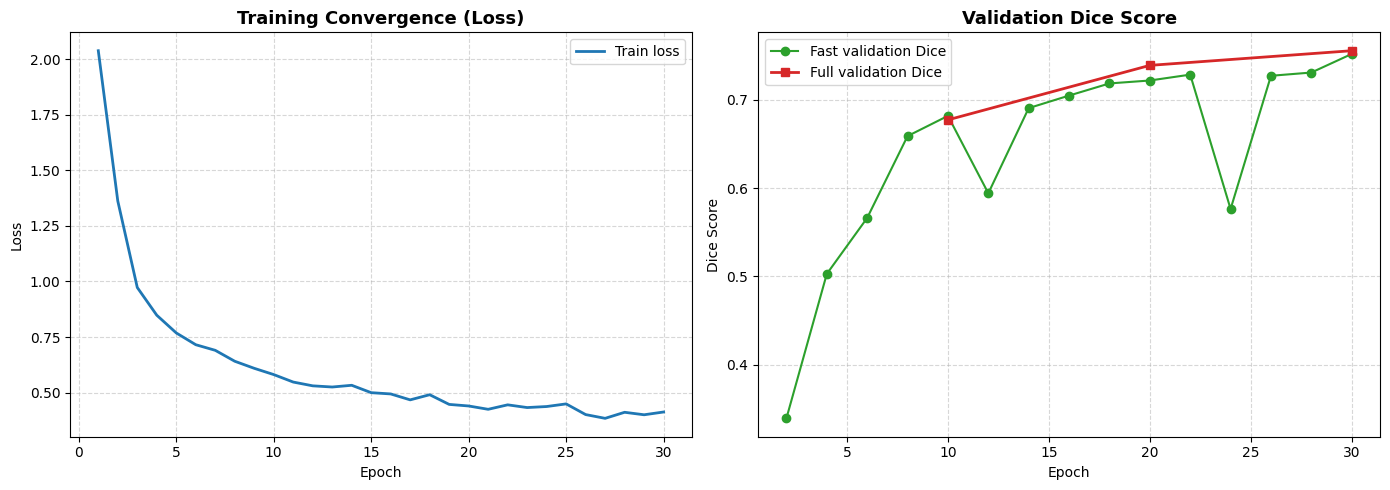

In [ ]:

# 1. Nạp history trực tiếp từ file checkpoint đã lưu trên Drive/Local
checkpoint_path = checkpoints_dir / "unet3d_brats_best.pth"
checkpoint = torch.load(checkpoint_path, map_location="cpu")
history = checkpoint.get("history", {})
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Đồ thị Training Loss
axes[0].plot(
    range(1, len(history["train_loss"]) + 1),
    history["train_loss"],
    label="Train loss",
    color="#1f77b4",
    lw=2,
)
axes[0].set_title("Training Convergence (Loss)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend()

# Đồ thị Validation Dice
axes[1].plot(
    history["fast_val_epochs"],
    history["fast_val_dice"],
    label="Fast validation Dice",
    color="#2ca02c",
    marker="o",
)
axes[1].plot(
    history["full_val_epochs"],
    history["full_val_dice"],
    label="Full validation Dice",
    color="#d62728",
    marker="s",
    lw=2,
)
axes[1].set_title("Validation Dice Score", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice Score")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:

print(
    f"{'MODEL':<14} | {'SPLIT':<10} | {'DICE':>7} | {'WT':>7} | {'TC':>7} | "
    f"{'ET':>7} | {'IOU':>7} | {'HD95 MM':>9} | {'BEST EPOCH':>10}"
)
print("=" * 116)
for model_name, run in MODEL_RUNS.items():
    for split_name in ("val", "test"):
        summary = run[f"{split_name}_summary"]
        print(
            f"{model_name:<14} | {split_name:<10} | {summary['dice_mean']:>7.4f} | "
            f"{summary['dice_wt']:>7.4f} | {summary['dice_tc']:>7.4f} | "
            f"{summary['dice_et']:>7.4f} | {summary['iou_mean']:>7.4f} | "
            f"{summary['hd95_mean']:>9.3f} | {run['best_epoch']:>10}"
        )
print("=" * 116)
print("Model selection used validation only; test metrics are final reporting metrics.")

MODEL          | SPLIT      |    DICE |      WT |      TC |      ET |     IOU |   HD95 MM | BEST EPOCH
unet3d         | val        |  0.7555 |  0.7613 |  0.7717 |  0.7334 |  0.6490 |    43.087 |         30
unet3d         | test       |  0.7361 |  0.7489 |  0.7534 |  0.7061 |  0.6310 |    43.058 |         30
Model selection used validation only; test metrics are final reporting metrics.


## 9. Trực quan hóa kết quả phân đoạn 3D đa mặt phẳng

In [ ]:
def visualize_slices(
    image_4d: np.ndarray,
    prediction: np.ndarray,
    case_id: str,
    model_name: str,
    ground_truth: Optional[np.ndarray] = None,
):
    flair = image_4d[3]
    pred = np.asarray(prediction).squeeze()
    gt = None if ground_truth is None else np.asarray(ground_truth).squeeze()
    selection_mask = gt if gt is not None and np.any(gt > 0) else pred

    z_sum = np.sum(selection_mask > 0, axis=(0, 1))
    y_sum = np.sum(selection_mask > 0, axis=(0, 2))
    x_sum = np.sum(selection_mask > 0, axis=(1, 2))
    z_idx = int(np.argmax(z_sum)) if z_sum.max() > 0 else flair.shape[2] // 2
    y_idx = int(np.argmax(y_sum)) if y_sum.max() > 0 else flair.shape[1] // 2
    x_idx = int(np.argmax(x_sum)) if x_sum.max() > 0 else flair.shape[0] // 2

    from matplotlib.colors import ListedColormap

    segmentation_cmap = ListedColormap(["none", "#e41a1c", "#4daf4a", "#ff7f00"])
    planes = [
        ("Axial", flair[:, :, z_idx], None if gt is None else gt[:, :, z_idx], pred[:, :, z_idx]),
        ("Coronal", flair[:, y_idx, :], None if gt is None else gt[:, y_idx, :], pred[:, y_idx, :]),
        ("Sagittal", flair[x_idx, :, :], None if gt is None else gt[x_idx, :, :], pred[x_idx, :, :]),
    ]
    columns = 3 if gt is not None else 2
    fig, axes = plt.subplots(3, columns, figsize=(5 * columns, 12))
    for row, (plane_name, base, target_mask, pred_mask) in enumerate(planes):
        axes[row, 0].imshow(base.T, cmap="gray", origin="lower")
        axes[row, 0].set_title(f"{plane_name} - FLAIR")
        axes[row, 0].axis("off")
        pred_column = 2 if gt is not None else 1
        if gt is not None:
            axes[row, 1].imshow(base.T, cmap="gray", origin="lower")
            axes[row, 1].imshow(target_mask.T, cmap=segmentation_cmap, vmin=0, vmax=3, alpha=0.5, origin="lower")
            axes[row, 1].set_title(f"{plane_name} - Ground truth")
            axes[row, 1].axis("off")
        axes[row, pred_column].imshow(base.T, cmap="gray", origin="lower")
        axes[row, pred_column].imshow(pred_mask.T, cmap=segmentation_cmap, vmin=0, vmax=3, alpha=0.5, origin="lower")
        axes[row, pred_column].set_title(f"{plane_name} - {model_name}")
        axes[row, pred_column].axis("off")
    plt.suptitle(f"3D segmentation - {case_id}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

Prediction saved with original affine: /content/drive/MyDrive/BraTS2023/predictions/BraTS-GLI-01021-000_unet3d_seg.nii.gz


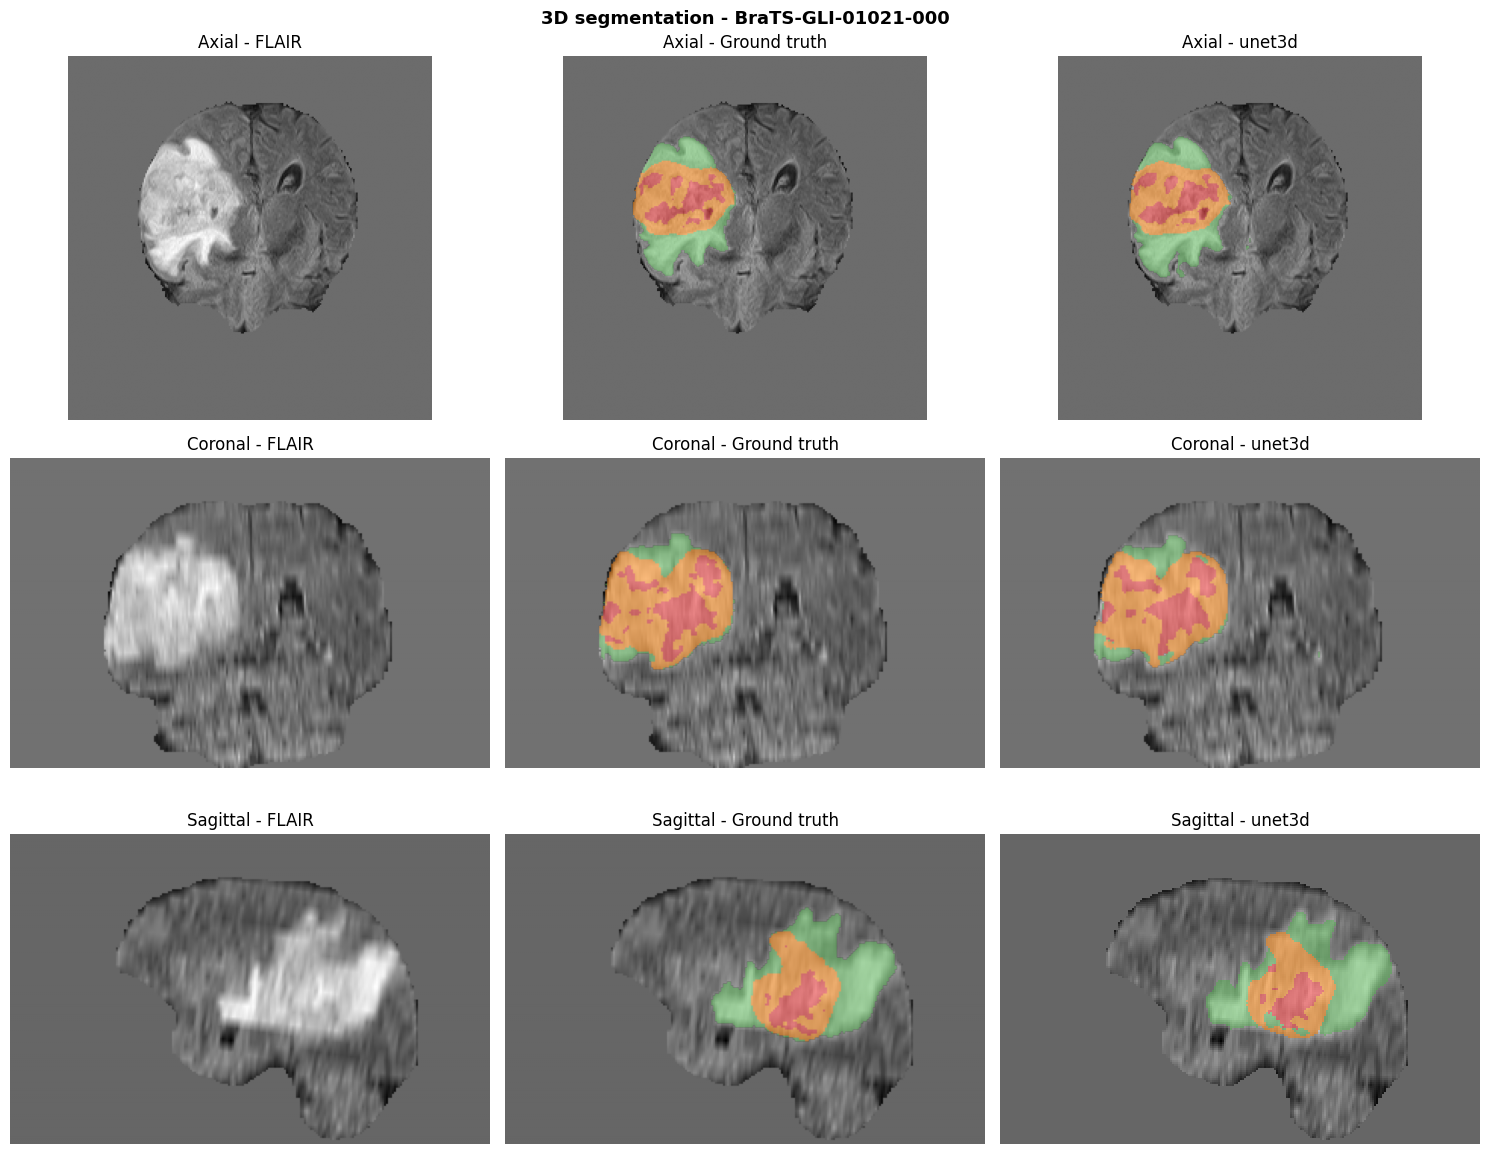

In [ ]:
# Demonstrate the selected checkpoint on one held-out test case.
sample_batch = next(iter(test_loader))
sample_image = sample_batch["image"].to(device)
sample_label = sample_batch["label"]
sample_case_id = sample_batch["case_id"][0]
sample_spacing = tuple(float(value) for value in sample_batch["spacing"][0].cpu().numpy())
sample_affine = sample_batch["affine"][0].cpu().numpy()

sample_prediction_tensor = predict_volume(best_model, sample_image)
sample_prediction = sample_prediction_tensor[0, 0].cpu().numpy().astype(np.uint8)
sample_metrics = compute_case_metrics(
    sample_prediction,
    sample_label[0, 0],
    sample_spacing,
    include_surface=True,
)

prediction_path = predictions_dir / f"{sample_case_id}_{best_model_name}_seg.nii.gz"
nib.save(nib.Nifti1Image(sample_prediction, sample_affine), prediction_path)
print(f"Prediction saved with original affine: {prediction_path}")

visualize_slices(
    sample_image[0].cpu().numpy(),
    sample_prediction,
    sample_case_id,
    best_model_name,
    ground_truth=sample_label[0].numpy(),
)

## 10. Research segmentation report

Bao cao nay trinh bay output dinh luong cua model. No khong dua ra chan doan,
khong de xuat dieu tri va khong duoc dung cho quyet dinh lam sang.

In [ ]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

def save_segmentation_figure(
    image_4d: np.ndarray,
    prediction: np.ndarray,
    output_file: Union[str, Path],
    ground_truth: Optional[np.ndarray] = None,
) -> Path:
    from matplotlib.colors import ListedColormap

    output_path = Path(output_file)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    flair = np.asarray(image_4d)[3]
    pred = np.asarray(prediction).squeeze()
    gt = None if ground_truth is None else np.asarray(ground_truth).squeeze()

    selection_mask = gt if gt is not None and np.any(gt > 0) else pred

    z_sum = np.sum(selection_mask > 0, axis=(0, 1))
    y_sum = np.sum(selection_mask > 0, axis=(0, 2))
    x_sum = np.sum(selection_mask > 0, axis=(1, 2))

    z_idx = int(np.argmax(z_sum)) if z_sum.max() > 0 else flair.shape[2] // 2
    y_idx = int(np.argmax(y_sum)) if y_sum.max() > 0 else flair.shape[1] // 2
    x_idx = int(np.argmax(x_sum)) if x_sum.max() > 0 else flair.shape[0] // 2

    segmentation_cmap = ListedColormap(
        ["none", "#e41a1c", "#4daf4a", "#ff7f00"]
    )

    planes = [
        ("Axial", flair[:, :, z_idx], None if gt is None else gt[:, :, z_idx], pred[:, :, z_idx]),
        ("Coronal", flair[:, y_idx, :], None if gt is None else gt[:, y_idx, :], pred[:, y_idx, :]),
        ("Sagittal", flair[x_idx, :, :], None if gt is None else gt[x_idx, :, :], pred[x_idx, :, :]),
    ]

    columns = 3 if gt is not None else 2
    figure, axes = plt.subplots(3, columns, figsize=(12, 12))

    if columns == 2:
        axes = np.asarray(axes).reshape(3, 2)

    for row, (plane_name, base, target_mask, pred_mask) in enumerate(planes):
        axes[row, 0].imshow(base.T, cmap="gray", origin="lower")
        axes[row, 0].set_title(f"{plane_name} - FLAIR")
        axes[row, 0].axis("off")

        prediction_column = 2 if gt is not None else 1

        if gt is not None:
            axes[row, 1].imshow(base.T, cmap="gray", origin="lower")
            axes[row, 1].imshow(
                target_mask.T,
                cmap=segmentation_cmap,
                vmin=0,
                vmax=3,
                alpha=0.5,
                origin="lower",
            )
            axes[row, 1].set_title(f"{plane_name} - Ground truth")
            axes[row, 1].axis("off")

        axes[row, prediction_column].imshow(
            base.T,
            cmap="gray",
            origin="lower",
        )
        axes[row, prediction_column].imshow(
            pred_mask.T,
            cmap=segmentation_cmap,
            vmin=0,
            vmax=3,
            alpha=0.5,
            origin="lower",
        )
        axes[row, prediction_column].set_title(
            f"{plane_name} - Model prediction"
        )
        axes[row, prediction_column].axis("off")

    legend_handles = [
        Patch(
            facecolor="#e41a1c",
            label="Label 1 - Necrotic/non-enhancing tumor",
        ),
        Patch(
            facecolor="#4daf4a",
            label="Label 2 - Edema",
        ),
        Patch(
            facecolor="#ff7f00",
            label="Label 3 - Enhancing tumor",
        ),
    ]

    figure.suptitle(
        "3D Brain Tumor Segmentation",
        fontsize=14,
        fontweight="bold",
    )

    figure.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=1,
        fontsize=9,
        frameon=True,
        bbox_to_anchor=(0.5, 0.01),
    )

    figure.tight_layout(rect=[0, 0.12, 1, 0.96])
    figure.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(figure)

    return output_path

In [ ]:
from fpdf import FPDF


class ResearchSegmentationReport(FPDF):
    def header(self):
        self.set_font("Helvetica", "B", 14)
        self.cell(
            0,
            8,
            "BRAIN TUMOR SEGMENTATION RESEARCH REPORT",
            new_x="LMARGIN",
            new_y="NEXT",
            align="C",
        )
        self.set_font("Helvetica", "I", 8)
        self.cell(
            0,
            5,
            "Research use only - not for clinical diagnosis or treatment",
            new_x="LMARGIN",
            new_y="NEXT",
            align="C",
        )
        self.ln(3)

    def footer(self):
        self.set_y(-15)
        self.set_font("Helvetica", "I", 8)
        self.cell(
            0,
            10,
            f"Page {self.page_no()} | SIC Capstone 2026",
            align="C",
        )


def export_research_report(
    case_id: str,
    model_name: str,
    spacing: Tuple[float, float, float],
    volumes: Dict[str, float],
    output_file: Union[str, Path],
    metrics: Optional[Dict[str, float]] = None,
    segmentation_image: Optional[Union[str, Path]] = None,
) -> Path:
    output_path = Path(output_file)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    pdf = ResearchSegmentationReport()
    pdf.set_auto_page_break(auto=True, margin=20)
    pdf.add_page()

    # Section 1: Case and model
    pdf.set_font("Helvetica", "B", 11)
    pdf.cell(
        0,
        7,
        "1. CASE AND MODEL",
        new_x="LMARGIN",
        new_y="NEXT",
    )

    pdf.set_font("Helvetica", "", 9)
    pdf.cell(
        0,
        5,
        f"Case ID: {case_id}",
        new_x="LMARGIN",
        new_y="NEXT",
    )
    pdf.cell(
        0,
        5,
        f"Model: {model_name}",
        new_x="LMARGIN",
        new_y="NEXT",
    )
    pdf.cell(
        0,
        5,
        f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}",
        new_x="LMARGIN",
        new_y="NEXT",
    )
    pdf.cell(
        0,
        5,
        (
            f"Voxel spacing: {spacing[0]:.4f} x "
            f"{spacing[1]:.4f} x {spacing[2]:.4f} mm"
        ),
        new_x="LMARGIN",
        new_y="NEXT",
    )
    pdf.ln(3)

    # Section 2: Predicted volumes
    pdf.set_font("Helvetica", "B", 11)
    pdf.cell(
        0,
        7,
        "2. PREDICTED VOLUMES",
        new_x="LMARGIN",
        new_y="NEXT",
    )

    pdf.set_font("Helvetica", "B", 9)
    pdf.cell(90, 6, "Region", border=1, align="C")
    pdf.cell(
        100,
        6,
        "Predicted volume (cm3)",
        border=1,
        align="C",
        new_x="LMARGIN",
        new_y="NEXT",
    )

    pdf.set_font("Helvetica", "", 9)
    for region_name, display_name in (
        ("wt", "Whole Tumor"),
        ("tc", "Tumor Core"),
        ("et", "Enhancing Tumor"),
    ):
        pdf.cell(90, 6, display_name, border=1)
        pdf.cell(
            100,
            6,
            f"{volumes[region_name]:.3f}",
            border=1,
            align="C",
            new_x="LMARGIN",
            new_y="NEXT",
        )

    pdf.ln(3)

    has_segmentation_image = segmentation_image is not None

    if has_segmentation_image:
        image_path = Path(segmentation_image)

        if not image_path.is_file():
            raise FileNotFoundError(
                f"Segmentation image not found: {image_path}"
            )

        # Section 3: Segmentation visualization
        pdf.add_page()
        pdf.set_font("Helvetica", "B", 11)
        pdf.cell(
            0,
            7,
            "3. MODEL SEGMENTATION VISUALIZATION",
            new_x="LMARGIN",
            new_y="NEXT",
        )

        pdf.set_font("Helvetica", "", 8)
        pdf.multi_cell(
            0,
            4,
            "FLAIR images with ground-truth and model-predicted "
            "segmentation overlays. Research visualization only.",
        )
        pdf.ln(3)

        pdf.image(
            str(image_path),
            x=15,
            y=45,
            w=180,
        )

    # Section 4 or 3: Reference-based metrics
    if metrics is not None:
        metrics_section = 4 if has_segmentation_image else 3

        pdf.add_page()
        pdf.set_font("Helvetica", "B", 11)
        pdf.cell(
            0,
            7,
            f"{metrics_section}. REFERENCE-BASED METRICS",
            new_x="LMARGIN",
            new_y="NEXT",
        )

        pdf.set_font("Helvetica", "", 8)
        pdf.multi_cell(
            0,
            4,
            "These metrics require a ground-truth mask and are "
            "evaluation results, not confidence scores.",
        )

        pdf.set_font("Helvetica", "B", 8)
        for title, width in (
            ("Region", 40),
            ("Dice", 30),
            ("IoU", 30),
            ("Precision", 30),
            ("Recall", 30),
            ("HD95 mm", 30),
        ):
            pdf.cell(width, 6, title, border=1, align="C")

        pdf.ln()
        pdf.set_font("Helvetica", "", 8)

        for region_name, display_name in (
            ("wt", "WT"),
            ("tc", "TC"),
            ("et", "ET"),
        ):
            values = [
                display_name,
                f"{metrics[f'dice_{region_name}']:.4f}",
                f"{metrics[f'iou_{region_name}']:.4f}",
                f"{metrics[f'precision_{region_name}']:.4f}",
                f"{metrics[f'recall_{region_name}']:.4f}",
                f"{metrics[f'hd95_{region_name}']:.3f}",
            ]

            for value, width in zip(
                values,
                (40, 30, 30, 30, 30, 30),
            ):
                pdf.cell(width, 6, value, border=1, align="C")

            pdf.ln()

    # Section limitations
    if metrics is not None:
        limitations_section = 5 if has_segmentation_image else 4
    else:
        limitations_section = 4 if has_segmentation_image else 3

    pdf.add_page()
    pdf.set_font("Helvetica", "B", 11)
    pdf.cell(
        0,
        7,
        f"{limitations_section}. LIMITATIONS",
        new_x="LMARGIN",
        new_y="NEXT",
    )

    pdf.set_font("Helvetica", "", 9)
    pdf.multi_cell(
        0,
        5,
        "This automated segmentation is a research output. It has not "
        "been clinically validated, does not constitute a diagnosis, "
        "and must not be used for treatment or radiotherapy planning.",
    )

    pdf.output(str(output_path))
    print(f"Research report saved: {output_path}")

    return output_path

In [ ]:

sample_volumes = {
    region: sample_metrics[f"volume_cm3_{region}"]
    for region in REGION_BUILDERS
}

# Save the prediction visualization as an image
segmentation_figure_path = reports_dir / (
    f"{sample_case_id}_{best_model_name}_segmentation.png"
)

save_segmentation_figure(
    image_4d=sample_image[0].cpu().numpy(),
    prediction=sample_prediction,
    ground_truth=sample_label[0].numpy(),
    output_file=segmentation_figure_path,
)

print(f"Segmentation figure saved: {segmentation_figure_path}")
print(f"Figure exists: {segmentation_figure_path.exists()}")

# Export PDF with the segmentation image
sample_report_path = reports_dir / (
    f"{sample_case_id}_{best_model_name}_research_report.pdf"
)

export_research_report(
    case_id=sample_case_id,
    model_name=best_model_name,
    spacing=sample_spacing,
    volumes=sample_volumes,
    metrics=sample_metrics,
    output_file=sample_report_path,
    segmentation_image=segmentation_figure_path,
)

Segmentation figure saved: /content/drive/MyDrive/BraTS2023/reports/BraTS-GLI-01021-000_unet3d_segmentation.png
Figure exists: True
Research report saved: /content/drive/MyDrive/BraTS2023/reports/BraTS-GLI-01021-000_unet3d_research_report.pdf


PosixPath('/content/drive/MyDrive/BraTS2023/reports/BraTS-GLI-01021-000_unet3d_research_report.pdf')